# **Problem Statement**

## Business Context

A sales forecast is a prediction of future sales revenue based on historical data, industry trends, and the status of the current sales pipeline. Businesses use the sales forecast to estimate weekly, monthly, quarterly, and annual sales totals. A company needs to make an accurate sales forecast as it adds value across an organization and helps the different verticals to chalk out their future course of action.

Forecasting helps an organization plan its sales operations by region and provides valuable insights to the supply chain team regarding the procurement of goods and materials. An accurate sales forecast process has many benefits which include improved decision-making about the future and reduction of sales pipeline and forecast risks. Moreover, it helps to reduce the time spent in planning territory coverage and establish benchmarks that can be used to assess trends in the future.

## Objective

SuperKart is a retail chain operating supermarkets and food marts across various tier cities, offering a wide range of products. To optimize its inventory management and make informed decisions around regional sales strategies, SuperKart wants to accurately forecast the sales revenue of its outlets for the upcoming quarter.

To operationalize these insights at scale, the company has partnered with a data science firm—not just to build a predictive model based on historical sales data, but to develop and deploy a robust forecasting solution that can be integrated into SuperKart’s decision-making systems and used across its network of stores.

## Data Description

The data contains the different attributes of the various products and stores.The detailed data dictionary is given below.

- **Product_Id** - unique identifier of each product, each identifier having two letters at the beginning followed by a number.
- **Product_Weight** - weight of each product
- **Product_Sugar_Content** - sugar content of each product like low sugar, regular and no sugar
- **Product_Allocated_Area** - ratio of the allocated display area of each product to the total display area of all the products in a store
- **Product_Type** - broad category for each product like meat, snack foods, hard drinks, dairy, canned, soft drinks, health and hygiene, baking goods, bread, breakfast, frozen foods, fruits and vegetables, household, seafood, starchy foods, others
- **Product_MRP** - maximum retail price of each product
- **Store_Id** - unique identifier of each store
- **Store_Establishment_Year** - year in which the store was established
- **Store_Size** - size of the store depending on sq. feet like high, medium and low
- **Store_Location_City_Type** - type of city in which the store is located like Tier 1, Tier 2 and Tier 3. Tier 1 consists of cities where the standard of living is comparatively higher than its Tier 2 and Tier 3 counterparts.
- **Store_Type** - type of store depending on the products that are being sold there like Departmental Store, Supermarket Type 1, Supermarket Type 2 and Food Mart
- **Product_Store_Sales_Total** - total revenue generated by the sale of that particular product in that particular store


# **Installing and Importing the necessary libraries**

In [1]:
#Installing the libraries with the specified versions
!pip install numpy==2.0.2 pandas==2.2.2 scikit-learn==1.6.1 matplotlib==3.10.0 seaborn==0.13.2 joblib==1.4.2 xgboost==2.1.4 requests==2.32.3 huggingface_hub==0.30.1 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 301.8/301.8 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.6/223.6 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 481.2/481.2 kB 13.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.3 which is incompatible.
google-adk 1.25.1 requires requests<3.0.0,>=2.32.4, but you have requests 2.32.3 which is incompatible.
diffusers 0.36.0 requires huggingface-hub<2.0,>=0.34.0, but you have huggingface-hub 0.30.1 which is incompatible.
transformers 5.0.0 requires huggingface-hub<2.0,>=1.3.0, but you have huggingface-hub 0.30.1 which is incompatible.
gradio 5.50.0 requires huggingface-hub<2.0,>=0.33.5, but you have hugging

**Note:**

- After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab) and run all cells sequentially from the next cell.

- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [2]:
import warnings
warnings.filterwarnings("ignore")

# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# For splitting the dataset
from sklearn.model_selection import train_test_split

# Libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 100)


# Libraries different ensemble classifiers
from sklearn.ensemble import (
    BaggingRegressor,
    RandomForestRegressor,
    AdaBoostRegressor,
    GradientBoostingRegressor,
)
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor

from sklearn import metrics

# Libraries to get different metric scores
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error
)

# To create the pipeline
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline,Pipeline

# To tune different models and standardize
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler,OneHotEncoder

# To serialize the model
import joblib

# os related functionalities
import os

# API request
import requests

# for hugging face space authentication to upload files
from huggingface_hub import login, HfApi

# **Loading the dataset**

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
products_stores = pd.read_csv("/content/drive/MyDrive/GreatLearning/MLOps/SuperKart.csv")

In [5]:
# creating a copy of the data
data = products_stores.copy()

# **Data Overview**

## **Checking the first 5 rows**

In [6]:
data.head(5)

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36


## **Checking the shape of the data**




In [7]:
data.shape

(8763, 12)

## **Checking the attribute types**

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Product_Id                 8763 non-null   object 
 1   Product_Weight             8763 non-null   float64
 2   Product_Sugar_Content      8763 non-null   object 
 3   Product_Allocated_Area     8763 non-null   float64
 4   Product_Type               8763 non-null   object 
 5   Product_MRP                8763 non-null   float64
 6   Store_Id                   8763 non-null   object 
 7   Store_Establishment_Year   8763 non-null   int64  
 8   Store_Size                 8763 non-null   object 
 9   Store_Location_City_Type   8763 non-null   object 
 10  Store_Type                 8763 non-null   object 
 11  Product_Store_Sales_Total  8763 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 821.7+ KB


## **Checking the statistical summary**

In [9]:
data.describe()

,Product_Weight,Product_Allocated_Area,Product_MRP,Store_Establishment_Year,Product_Store_Sales_Total
count,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000
mean,12.653792,0.068786,147.032539,2002.032751,3464.003640
std,2.217320,0.048204,30.694110,8.388381,1065.630494
min,4.000000,0.004000,31.000000,1987.000000,33.000000
25%,11.150000,0.031000,126.160000,1998.000000,2761.715000
50%,12.660000,0.056000,146.740000,2009.000000,3452.340000
75%,14.180000,0.096000,167.585000,2009.000000,4145.165000
max,22.000000,0.298000,266.000000,2009.000000,8000.000000


Average price of the product is 147.03

Average sale of the store is  is 3464.

On an average, ~600 dollars have been spent on adversiting.

The products are priced between 31 to 266 .

## **Checking Null Values**

In [10]:
data.isnull().sum()

,0
Product_Id,0
Product_Weight,0
Product_Sugar_Content,0
Product_Allocated_Area,0
Product_Type,0
Product_MRP,0
Store_Id,0
Store_Establishment_Year,0
Store_Size,0
Store_Location_City_Type,0


No null values found.

## **Checking for duplicate values**

In [11]:
# checking for duplicate values
data.duplicated().sum()

np.int64(0)

* There are no duplicate values in the data

# **Exploratory Data Analysis (EDA)**

## Univariate Analysis

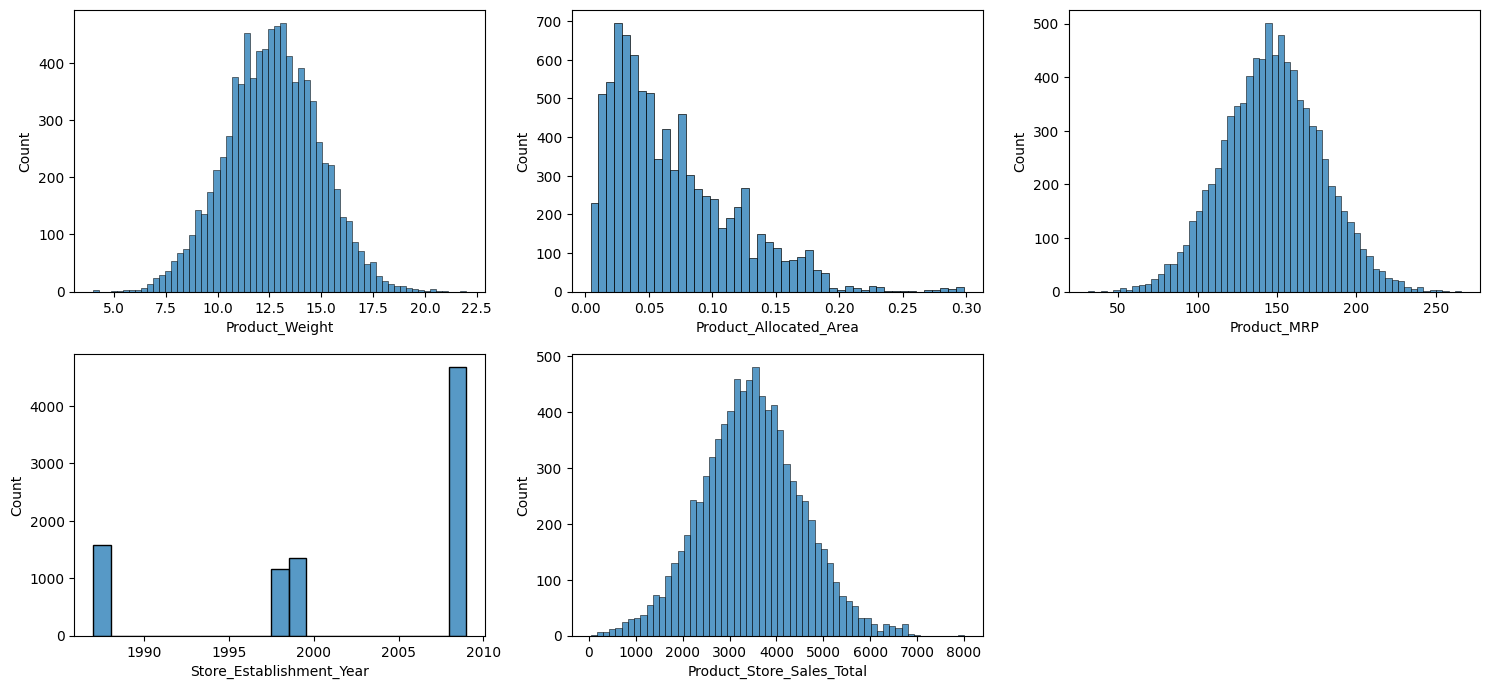

In [12]:
# defining the figure size
plt.figure(figsize=(15, 10))

# defining the list of numerical features to plot
features = data.select_dtypes(include=['number']).columns.tolist()

# creating the histograms
for i, feature in enumerate(features):
    plt.subplot(3, 3, i+1)    # assign a subplot in the main plot
    sns.histplot(data=data, x=feature)    # plot the histogram

plt.tight_layout()    # to add spacing between plots
plt.show()

* Product_Allocated_Area has right-skewed distributions.
* others have balanced distribution.

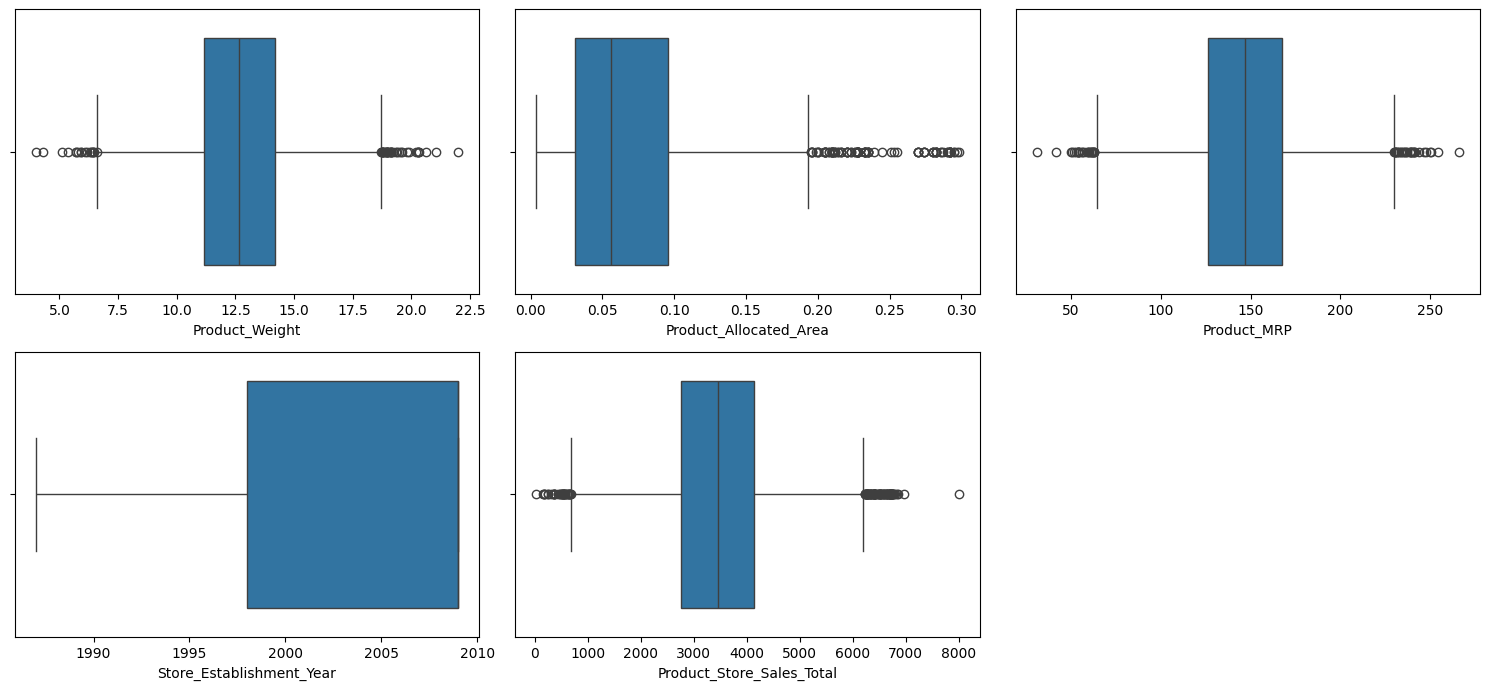

In [13]:
plt.figure(figsize=(15, 10))


for i, feature in enumerate(features):
    plt.subplot(3, 3,i+1)
    sns.boxplot(data=data, x=feature)


plt.tight_layout()    # to add spacing between plots
plt.show()


## Bivariate Analysis

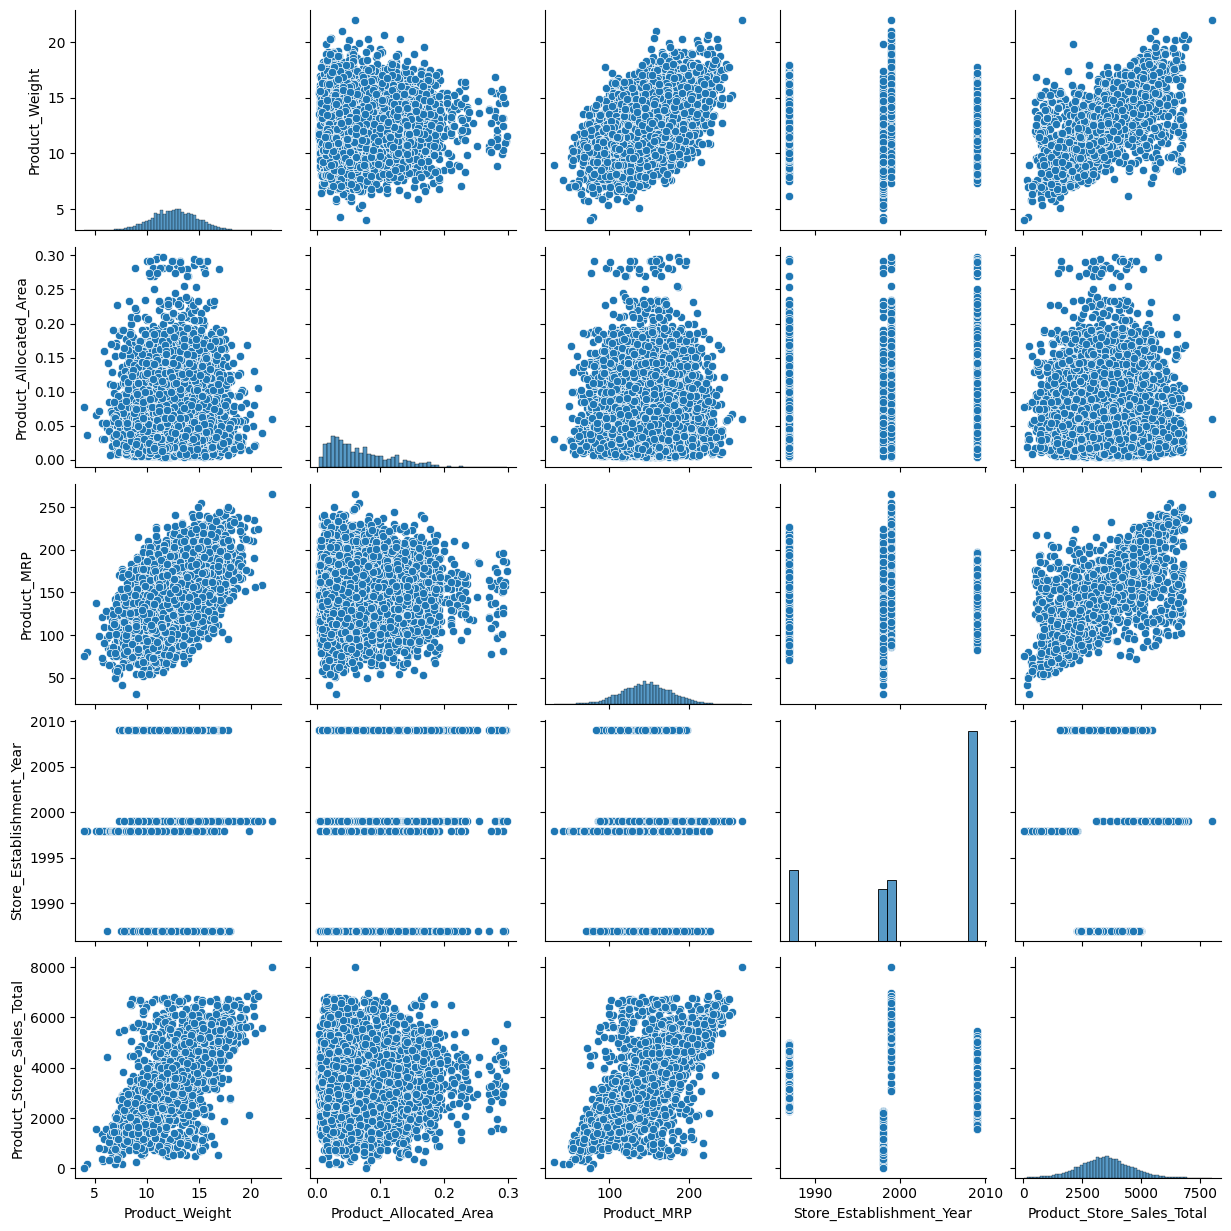

In [14]:
sns.pairplot(data);

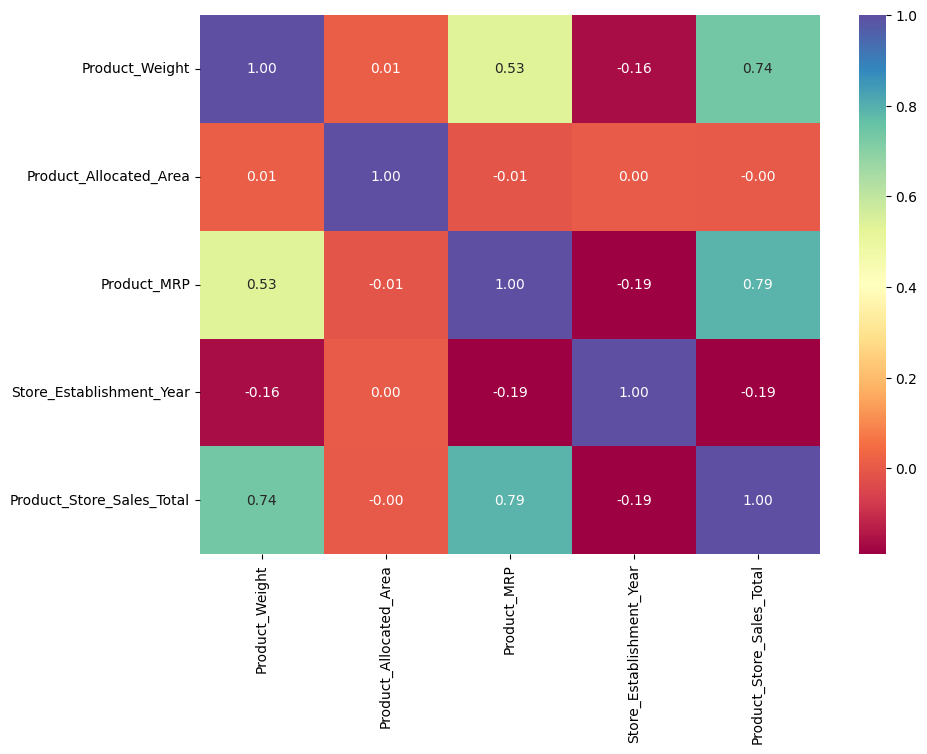

In [15]:
# defining the figure size
plt.figure(figsize=(10, 7))

# plotting the correlation heatmap
sns.heatmap(data.corr(numeric_only = True), annot=True, fmt='0.2f', cmap='Spectral');


product store sales total is highly corelated with Product weight and Product MRP.

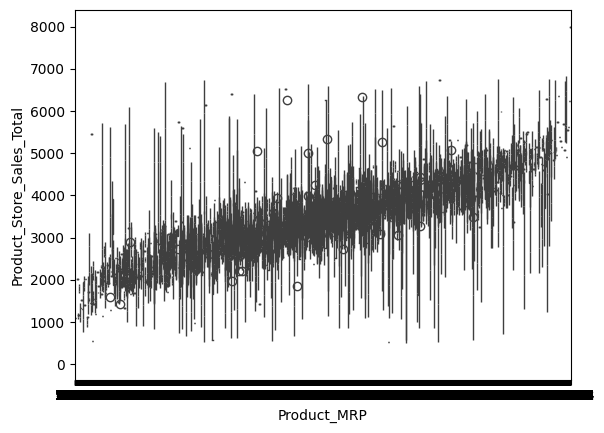

In [16]:
sns.boxplot(data=data, y='Product_Store_Sales_Total', x='Product_MRP');



<Axes: xlabel='Product_Weight', ylabel='Product_Store_Sales_Total'>

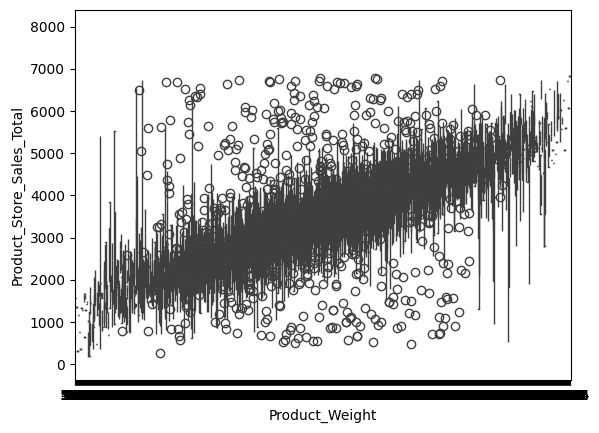

In [17]:

sns.boxplot(x="Product_Weight", y="Product_Store_Sales_Total", data=data, orient="vertical")

# **Data Preprocessing**

In [18]:
# defining the explanatory (independent) and response (dependent) variables
X = data.drop('Product_Store_Sales_Total', axis=1)
y = data['Product_Store_Sales_Total']

In [19]:
# Splitting data into training, validation and test sets:
# first we split data into 2 parts, say temporary and test

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1
)

# then we split the temporary set into train and validation

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=1
)
print(X_train.shape, X_val.shape, X_test.shape)

(5257, 11) (1753, 11) (1753, 11)


##  Dummy Value setup


In [20]:
# Creating dummy variables for categorical variables
X_train = pd.get_dummies(data=X_train, drop_first=True)
X_val = pd.get_dummies(data=X_val, drop_first=True)
X_test = pd.get_dummies(data=X_test, drop_first=True)

# **Model Building**

## Define functions for Model Evaluation

In [21]:
# function to compute adjusted R-squared
def adj_r2_score(predictors, targets, predictions):
    r2 = r2_score(targets, predictions)
    n = predictors.shape[0]
    k = predictors.shape[1]
    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))


# function to compute different metrics to check performance of a regression model
def model_performance_regression(model, predictors, target):
    """
    Function to compute different metrics to check regression model performance

    model: regressor
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    r2 = r2_score(target, pred)  # to compute R-squared
    adjr2 = adj_r2_score(predictors, target, pred)  # to compute adjusted R-squared
    rmse = np.sqrt(mean_squared_error(target, pred))  # to compute RMSE
    mae = mean_absolute_error(target, pred)  # to compute MAE
    mape = mean_absolute_percentage_error(target, pred)  # to compute MAPE

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "RMSE": rmse,
            "MAE": mae,
            "R-squared": r2,
            "Adj. R-squared": adjr2,
            "MAPE": mape,
        },
        index=[0],
    )

    return df_perf

The ML models to be built can be any two out of the following:
1. Decision Tree
2. Bagging
3. Random Forest
4. AdaBoost
5. Gradient Boosting
6. XGBoost

In [22]:
from sklearn.model_selection import KFold, cross_val_score

models = []  # Empty list to store all the models

# Appending models into the list, using Regressors for a regression task
models.append(("Bagging", BaggingRegressor(random_state=1)))
models.append(("Xgboost", XGBRegressor(random_state=1)))
models.append(("Decision Tree", DecisionTreeRegressor(random_state=1)))

results = []  # Empty list to store all model's CV scores
names = []  # Empty list to store name of the models
score = []

# loop through all models to get the mean cross validated score
print("\n" "Cross-Validation Performance:" "\n")
for name, model in models:
    # Using 'r2' as a scoring metric for regression
    scoring = "r2"
    # Using KFold for regression tasks
    kfold = KFold(
        n_splits=5, shuffle=True, random_state=1
    )  # Setting number of splits equal to 5
    cv_result = cross_val_score(
        estimator=model, X=X_train, y=y_train, scoring=scoring, cv=kfold
    )
    results.append(cv_result)
    names.append(name)
    print("{}: {}".format(name, cv_result.mean() * 100))

print("\n" "Validation Performance:" "\n")

# Align columns of X_val with X_train to prevent feature mismatch error
X_val_aligned = X_val.reindex(columns=X_train.columns, fill_value=0)

for name, model in models:
    model.fit(X_train, y_train)
    # Using r2_score for validation performance
    scores = r2_score(y_val, model.predict(X_val_aligned))
    score.append(scores)
    print("{}: {}".format(name, scores))


Cross-Validation Performance:

Bagging: 92.25905249376247
Xgboost: 91.96099500377919
Decision Tree: 91.05714782721941

Validation Performance:

Bagging: 0.9383086686734717
Xgboost: 0.9323139717057817
Decision Tree: 0.9338102276688611


# **Model Performance Improvement - Hyperparameter Tuning**

In [23]:
# Selecting specific features to reduce computation time during hyperparameter tuning
selected_features = [
    'Product_Weight',
    'Product_Sugar_Content',
    'Product_Allocated_Area',
    'Product_Type',
    'Product_MRP',
    'Store_Establishment_Year',
    'Store_Size',
    'Store_Location_City_Type',
    'Store_Type'
]

# Redefine X with selected features only
X_selected = data[selected_features]
y = data['Product_Store_Sales_Total']

print(f"Original number of features: {X.shape[1]}")
print(f"Selected number of features: {X_selected.shape[1]}")
print(f"\nSelected features: {selected_features}")

Original number of features: 11
Selected number of features: 9

Selected features: ['Product_Weight', 'Product_Sugar_Content', 'Product_Allocated_Area', 'Product_Type', 'Product_MRP', 'Store_Establishment_Year', 'Store_Size', 'Store_Location_City_Type', 'Store_Type']


In [24]:
# Re-splitting data with selected features
X_temp, X_test, y_temp, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=1
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=1
)

print(f"Training set shape: {X_train.shape}")
print(f"Validation set shape: {X_val.shape}")
print(f"Test set shape: {X_test.shape}")

Training set shape: (5257, 9)
Validation set shape: (1753, 9)
Test set shape: (1753, 9)


In [25]:
# Creating dummy variables for categorical variables
X_train_tuned = pd.get_dummies(data=X_train, drop_first=True)
X_val_tuned = pd.get_dummies(data=X_val, drop_first=True)
X_test_tuned = pd.get_dummies(data=X_test, drop_first=True)

# Align validation and test sets with training set columns
X_val_tuned = X_val_tuned.reindex(columns=X_train_tuned.columns, fill_value=0)
X_test_tuned = X_test_tuned.reindex(columns=X_train_tuned.columns, fill_value=0)

print(f"\nShape after encoding:")
print(f"X_train_tuned: {X_train_tuned.shape}")
print(f"X_val_tuned: {X_val_tuned.shape}")
print(f"X_test_tuned: {X_test_tuned.shape}")


Shape after encoding:
X_train_tuned: (5257, 29)
X_val_tuned: (1753, 29)
X_test_tuned: (1753, 29)


In [28]:
# Bagging Hyperparameter Tuning
model_bag = BaggingRegressor(random_state=1)

# Parameter grid for Bagging (optimized for faster execution)
param_grid_bag = {
    "n_estimators": [50, 100, 150],
    "max_features": [0.7, 0.9, 1.0],
    "max_samples": [0.7, 0.9, 1.0],
    "bootstrap": [True, False]
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.r2_score)

# Calling GridSearchCV for Bagging
print("Starting Bagging Regressor Hyperparameter Tuning...")
print(f"Total combinations to evaluate: {len(param_grid_bag['n_estimators']) * len(param_grid_bag['max_features']) * len(param_grid_bag['max_samples']) * len(param_grid_bag['bootstrap'])}\n")

grid_cv_bag = GridSearchCV(
    estimator=model_bag,
    param_grid=param_grid_bag,
    scoring=scorer,
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Fitting parameters in GridSearchCV
grid_cv_bag.fit(X_train_tuned, y_train)

print("\n" + "="*70)
print("Bagging - Best Parameters: {}".format(grid_cv_bag.best_params_))
print("Bagging - Best CV R² Score: {:.4f}".format(grid_cv_bag.best_score_))
print("="*70)

# Decision Tree Hyperparameter Tuning
model_dt = DecisionTreeRegressor(random_state=1)

# Parameter grid for Decision Tree
param_grid_dt = {
    "criterion": ["squared_error", "friedman_mse"],
    "max_depth": [5, 7, 10, 15],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.r2_score)

# Calling GridSearchCV for Decision Tree
print("Starting Decision Tree Hyperparameter Tuning...")
print(f"Total combinations to evaluate: {len(param_grid_dt['criterion']) * len(param_grid_dt['max_depth']) * len(param_grid_dt['min_samples_split']) * len(param_grid_dt['min_samples_leaf'])}\n")

grid_cv_dt = GridSearchCV(
    estimator=model_dt,
    param_grid=param_grid_dt,
    scoring=scorer,
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Fitting parameters in GridSearchCV
grid_cv_dt.fit(X_train_tuned, y_train)

print("\n" + "="*70)
print("Decision Tree - Best Parameters: {}".format(grid_cv_dt.best_params_))
print("Decision Tree - Best CV R² Score: {:.4f}".format(grid_cv_dt.best_score_))
print("="*70)


Starting Bagging Regressor Hyperparameter Tuning...
Total combinations to evaluate: 54

Fitting 5 folds for each of 54 candidates, totalling 270 fits

Bagging - Best Parameters: {'bootstrap': True, 'max_features': 1.0, 'max_samples': 0.7, 'n_estimators': 150}
Bagging - Best CV R² Score: 0.9236
Starting Decision Tree Hyperparameter Tuning...
Total combinations to evaluate: 72

Fitting 5 folds for each of 72 candidates, totalling 360 fits

Decision Tree - Best Parameters: {'criterion': 'friedman_mse', 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2}
Decision Tree - Best CV R² Score: 0.9015


In [29]:
# Evaluate the best Bagging model on validation set
best_bag_model = grid_cv_bag.best_estimator_

print("\nBagging - Training Performance:")
bag_train_perf = model_performance_regression(best_bag_model, X_train_tuned, y_train)
print(bag_train_perf)

print("\nBagging - Validation Performance:")
bag_val_perf = model_performance_regression(best_bag_model, X_val_tuned, y_val)
print(bag_val_perf)


Bagging - Training Performance:
         RMSE        MAE  R-squared  Adj. R-squared      MAPE
0  146.713879  55.443102   0.981009        0.980903  0.020397

Bagging - Validation Performance:
         RMSE         MAE  R-squared  Adj. R-squared      MAPE
0  265.176401  101.640869    0.93735        0.936296  0.044361


In [32]:
# Evaluate the best Decision Tree model on validation set
best_dt_model = grid_cv_dt.best_estimator_

print("\nDecision Tree - Training Performance:")
dt_train_perf = model_performance_regression(best_dt_model, X_train_tuned, y_train)
print(dt_train_perf)

print("\nDecision Tree - Validation Performance:")
dt_val_perf = model_performance_regression(best_dt_model, X_val_tuned, y_val)
print(dt_val_perf)


Decision Tree - Training Performance:
         RMSE         MAE  R-squared  Adj. R-squared      MAPE
0  248.963317  116.412172   0.945313         0.94501  0.040756

Decision Tree - Validation Performance:
         RMSE         MAE  R-squared  Adj. R-squared      MAPE
0  292.543747  141.164171   0.923752        0.922468  0.057905


## Hyperparameter Tuning for XGBoost Regressor



In [33]:
# XGBoost Hyperparameter Tuning
model_xgb = XGBRegressor(random_state=1, verbosity=0)

# Parameter grid for XGBoost (optimized for faster execution)
param_grid_xgb = {
    "n_estimators": [100, 150, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1, 0.2],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.r2_score)

# Calling GridSearchCV for XGBoost
print("Starting XGBoost Hyperparameter Tuning...")
print(f"Total combinations to evaluate: {len(param_grid_xgb['n_estimators']) * len(param_grid_xgb['max_depth']) * len(param_grid_xgb['learning_rate']) * len(param_grid_xgb['subsample']) * len(param_grid_xgb['colsample_bytree'])}\n")

grid_cv_xgb = GridSearchCV(
    estimator=model_xgb,
    param_grid=param_grid_xgb,
    scoring=scorer,
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Fitting parameters in GridSearchCV
grid_cv_xgb.fit(X_train_tuned, y_train)

print("\n" + "="*70)
print("XGBoost - Best Parameters: {}".format(grid_cv_xgb.best_params_))
print("XGBoost - Best CV R² Score: {:.4f}".format(grid_cv_xgb.best_score_))
print("="*70)

Starting XGBoost Hyperparameter Tuning...
Total combinations to evaluate: 108

Fitting 5 folds for each of 108 candidates, totalling 540 fits

XGBoost - Best Parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 100, 'subsample': 0.8}
XGBoost - Best CV R² Score: 0.9209


In [34]:
# Evaluate the best XGBoost model on validation set
best_xgb_model = grid_cv_xgb.best_estimator_

print("\nXGBoost - Training Performance:")
xgb_train_perf = model_performance_regression(best_xgb_model, X_train_tuned, y_train)
print(xgb_train_perf)

print("\nXGBoost - Validation Performance:")
xgb_val_perf = model_performance_regression(best_xgb_model, X_val_tuned, y_val)
print(xgb_val_perf)


XGBoost - Training Performance:
         RMSE       MAE  R-squared  Adj. R-squared      MAPE
0  153.737357  67.42319   0.979147        0.979031  0.023771

XGBoost - Validation Performance:
         RMSE         MAE  R-squared  Adj. R-squared      MAPE
0  269.991109  114.529465   0.935055        0.933962  0.048939


# **Model Performance Comparison, Final Model Selection, and Serialization**

In [35]:
# Creating a comprehensive comparison of all tuned models
models_comparison = pd.DataFrame({
    'Model': ['Decision Tree', 'Bagging', 'XGBoost'],
    'Best CV R² Score': [
        grid_cv_dt.best_score_,
        grid_cv_bag.best_score_,
        grid_cv_xgb.best_score_
    ],
    'Validation R²': [
        dt_val_perf['R-squared'].values[0],
        bag_val_perf['R-squared'].values[0],
        xgb_val_perf['R-squared'].values[0]
    ],
    'Validation RMSE': [
        dt_val_perf['RMSE'].values[0],
        bag_val_perf['RMSE'].values[0],
        xgb_val_perf['RMSE'].values[0]
    ],
    'Validation MAE': [
        dt_val_perf['MAE'].values[0],
        bag_val_perf['MAE'].values[0],
        xgb_val_perf['MAE'].values[0]
    ],
    'Validation MAPE': [
        dt_val_perf['MAPE'].values[0],
        bag_val_perf['MAPE'].values[0],
        xgb_val_perf['MAPE'].values[0]
    ]
})

print("\n" + "="*100)
print("MODEL PERFORMANCE COMPARISON (After Hyperparameter Tuning)")
print("="*100)
print(models_comparison.to_string(index=False))
print("="*100)

# Identify the best model based on validation R² score
best_model_idx = models_comparison['Validation R²'].idxmax()
best_model_name = models_comparison.loc[best_model_idx, 'Model']
print(f"\n Best Model: {best_model_name}")
print(f"   Validation R² Score: {models_comparison.loc[best_model_idx, 'Validation R²']:.4f}")


MODEL PERFORMANCE COMPARISON (After Hyperparameter Tuning)
        Model  Best CV R² Score  Validation R²  Validation RMSE  Validation MAE  Validation MAPE
Decision Tree          0.901465       0.923752       292.543747      141.164171         0.057905
      Bagging          0.923554       0.937350       265.176401      101.640869         0.044361
      XGBoost          0.920877       0.935055       269.991109      114.529465         0.048939

 Best Model: Bagging
   Validation R² Score: 0.9374


## Serializing the Best Model (Bagging Regressor)

Since the Bagging Regressor emerged as the best model, we will now:
1. Build a **sklearn Pipeline** that includes preprocessing (OneHotEncoding) and the tuned Bagging model
2. Evaluate the pipeline on the test set
3. Serialize (save) the pipeline using **joblib** for deployment

In [2]:
# Build a deployment-ready pipeline with preprocessing + best Bagging model

# Define categorical and numerical columns from the selected features
categorical_features = ['Product_Sugar_Content', 'Product_Type', 'Store_Size',
                        'Store_Location_City_Type', 'Store_Type']
numerical_features = ['Product_Weight', 'Product_Allocated_Area', 'Product_MRP',
                      'Store_Establishment_Year']

# Create the column transformer for preprocessing
preprocessor = make_column_transformer(
    (OneHotEncoder(drop='first', handle_unknown='error', sparse_output=False), categorical_features),
    remainder='passthrough'  # Keep numerical features as-is
)

# Create the pipeline with preprocessor + best Bagging model
best_bag_params = grid_cv_bag.best_params_
print("Best Bagging Hyperparameters:")
print(best_bag_params)

final_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', BaggingRegressor(
        n_estimators=best_bag_params['n_estimators'],
        max_features=best_bag_params['max_features'],
        max_samples=best_bag_params['max_samples'],
        bootstrap=best_bag_params['bootstrap'],
        random_state=1
    ))
])

# Re-split using the ORIGINAL selected features (before dummy encoding) for the pipeline
X_selected = data[selected_features]
y = data['Product_Store_Sales_Total']

X_temp, X_test_pipe, y_temp, y_test_pipe = train_test_split(
    X_selected, y, test_size=0.2, random_state=1
)
X_train_pipe, X_val_pipe, y_train_pipe, y_val_pipe = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=1
)



# Fit the pipeline on training data
final_pipeline.fit(X_train_pipe, y_train_pipe)

# Evaluate on test set
y_test_pred = final_pipeline.predict(X_test_pipe)

test_r2 = r2_score(y_test_pipe, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test_pipe, y_test_pred))
test_mae = mean_absolute_error(y_test_pipe, y_test_pred)
test_mape = mean_absolute_percentage_error(y_test_pipe, y_test_pred)

print("\n" + "="*70)
print("BAGGING PIPELINE - TEST SET PERFORMANCE")
print("="*70)
print(f"R-squared:  {test_r2:.4f}")
print(f"RMSE:       {test_rmse:.4f}")
print(f"MAE:        {test_mae:.4f}")
print(f"MAPE:       {test_mape:.4f}")
print("="*70)

NameError: name 'make_column_transformer' is not defined

In [38]:
# Serialize the final pipeline using joblib
model_filename = 'superkart_bagging_pipeline.pkl'
joblib.dump(final_pipeline, model_filename)
print(f"✅ Pipeline saved as: {model_filename}")
print(f"   File size: {os.path.getsize(model_filename) / (1024*1024):.2f} MB")

# Verify the saved model by loading it back and making a test prediction
loaded_pipeline = joblib.load(model_filename)
verify_pred = loaded_pipeline.predict(X_test_pipe)
verify_r2 = r2_score(y_test_pipe, verify_pred)
print(f"\n✅ Verification - Loaded model R² on test set: {verify_r2:.4f}")
print(f"   Original model R² on test set:              {test_r2:.4f}")
print(f"   Match: {np.isclose(test_r2, verify_r2)}")

✅ Pipeline saved as: superkart_bagging_pipeline.pkl
   File size: 54.57 MB

✅ Verification - Loaded model R² on test set: 0.9261
   Original model R² on test set:              0.9261
   Match: True


In [39]:
# Demonstrate how to use the serialized model for new predictions
print("Sample prediction using the saved pipeline:")
print("="*70)

# Take a sample from the test set
sample = X_test_pipe.iloc[:3]
print("\nInput features:")
print(sample.to_string())

# Make prediction using the loaded pipeline
sample_pred = loaded_pipeline.predict(sample)
print("\nPredicted Product_Store_Sales_Total:")
for i, pred in enumerate(sample_pred):
    actual = y_test_pipe.iloc[i]
    print(f"  Sample {i+1}: Predicted = {pred:.2f}, Actual = {actual:.2f}, Error = {abs(actual - pred):.2f}")

Sample prediction using the saved pipeline:

Input features:
      Product_Weight Product_Sugar_Content  Product_Allocated_Area Product_Type  Product_MRP  Store_Establishment_Year Store_Size Store_Location_City_Type          Store_Type
7441           12.76             Low Sugar                   0.035  Snack Foods       158.59                      2009     Medium                   Tier 2   Supermarket Type2
6355           17.54             Low Sugar                   0.012  Soft Drinks       217.37                      1999     Medium                   Tier 1  Departmental Store
1271           12.02               Regular                   0.013  Soft Drinks       201.24                      1999     Medium                   Tier 1  Departmental Store

Predicted Product_Store_Sales_Total:
  Sample 1: Predicted = 3684.68, Actual = 3714.07, Error = 29.39
  Sample 2: Predicted = 6020.22, Actual = 5995.91, Error = 24.31
  Sample 3: Predicted = 4542.86, Actual = 4419.17, Error = 123.69


# **Deployment - Backend**

## Flask Web Framework


In [ ]:
# Create the backend_files directory if it doesn't exist
os.makedirs("backend_files", exist_ok=True)
print("✅ backend_files directory created")

In [ ]:
%%writefile backend_files/app.py
import joblib
import pandas as pd
from flask import Flask, request, jsonify

# Initialize Flask app with a name
app = Flask("Product Sales Predictor")

# Load the trained sales prediction model
model = joblib.load("superkart_bagging_pipeline.pkl")

# Define a route for the home page
@app.get('/')
def home():
    return "Welcome to Sale Prediction API"

# Define an endpoint to predict sale for a single product
@app.post('/v1/product')
def predict_sale():
    # Get JSON data from the request
    product_data = request.get_json()

    # Extract relevant product features from the input data
    sample = {
        'Product_Weight': product_data['productWeight'],
        'Product_Sugar_Content': product_data['productSugarContent'],
        'Product_Allocated_Area': product_data['productAllocatedArea'],
        'Product_Type': product_data['productType'],
        'Product_MRP': product_data['productMRP'],
        'Store_Establishment_Year': product_data['storeEstablishmentYear'],
        'Store_Size': product_data['storeSize'],
        'Store_Location_City_Type': product_data['storeLocationCityType'],
        'Store_Type': product_data['storeType']
    }

    # Convert the extracted data into a DataFrame
    input_data = pd.DataFrame([sample])

    # Make a sale prediction using the trained model
    prediction = model.predict(input_data).tolist()[0]

    # Return the prediction as a JSON response
    return jsonify({'Predicted_Sales': round(float(prediction), 2)})


# Run the Flask app
if __name__ == '__main__':
    app.run(host='0.0.0.0', port=7860, debug=True)

 * Serving Flask app 'Product Sales Predictor'
 * Debug mode: on


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug: * Restarting with watchdog (inotify)


In the given code snippet, the decorators `@app.get('/')`, `@app.post('/v1/product')` are used in **FlaskAPI**, a modern web framework for building APIs in Python.

**What is a Decorator?**\
In Python, a **decorator** is a function that modifies the behavior of another function. The `@` syntax is used to apply a decorator.


**`@app.get('/')`**
- Defines a **GET endpoint** at the root URL `/`.
- When someone sends a GET request to `/`, the `home()` function will be triggered.
- Returns a welcome message.
- Whenever a user clicks on the deployment web app link or API link, a GET request is automatically triggered in the background and sent to the API. As defined in the function, this request targets the homepage, and the user is greeted with a welcome message.

**Summary of flow of script**
1. **Model Loading (`joblib.load`)**  
   Loads a pre-trained ML model (`superkart_bagging_pipeline.pkl`) trained to predict sale based on product features.

2. **Flask App Setup**  
   Initializes a simple Flask web app (`Flask("Product Sale Predictor")`), which exposes endpoints over HTTP.

3. **Root Route (`/`)**  
   Returns a welcome message for basic API connectivity testing.

4. **Single Customer Prediction (`/v1/product`)**
   - Accepts a **JSON payload** with a single customer's features.
   - Converts the data into a Pandas DataFrame.
   - Runs the model’s `.predict()` method.
   - Returns a **human-readable result**: `Product sale"


5. **Model Inference**
   - Makes use of `.predict()` to infer sale.


**Why This Is Valuable**
- **Real-time ML integration:** Bridges the gap between data science and real-world business applications.
- **Scalable predictions:** Enables both real-time (single) and batch processing of customers.
- **Automation-ready:** Can trigger automated actions (e.g., customer retention emails) based on predictions.


## Dependencies File

In [ ]:
%%writefile backend_files/requirements.txt
flask==3.1.0
gunicorn==23.0.0
pandas==2.2.2
scikit-learn==1.6.1
joblib==1.4.2
numpy==2.0.2

Writing backend_files/requirements.txt


## Dockerfile

In [45]:
%%writefile backend_files/Dockerfile
FROM python:3.9-slim

# Set the working directory inside the container
WORKDIR /app

# Copy all files from the current directory to the container's working directory
COPY . .

# Install dependencies from the requirements file without using cache to reduce image size
RUN pip install --no-cache-dir -r requirements.txt

# Define the command to start the application using Gunicorn with 4 worker processes
# - `-w 4`: Uses 4 worker processes for handling requests
# - `-b 0.0.0.0:7860`: Binds the server to port 7860 on all network interfaces
# - `app:app`: Runs the Flask app (assuming `app.py` contains the Flask instance named `app`)
CMD ["gunicorn", "-w", "4", "-b", "0.0.0.0:7860", "app:app"]

Writing backend_files/Dockerfile


In [ ]:
    # Copy the serialized pipeline to backend_files directory for Docker deployment
    import shutil
    shutil.copy('superkart_bagging_pipeline.pkl', 'backend_files/superkart_bagging_pipeline.pkl')
    print("✅ Model file copied to backend_files/")

    # Verify all backend files are present
    for f in os.listdir("backend_files"):
        size = os.path.getsize(f"backend_files/{f}") / 1024
        print(f"  📄 {f} ({size:.1f} KB)")

## Setting up a Hugging Face Docker Space for the Backend

In [ ]:
# for hugging face space authentication to upload files
from huggingface_hub import login, HfApi

access_key = "---------------------"  # Your Hugging Face token created from access keys in write mode
repo_id = "user_name/space_name"  # Your Hugging Face space id

# Login to Hugging Face platform with the access token
login(token="access_key")

# Initialize the API
api = HfApi()

# Upload Streamlit app files stored in the folder called deployment_files
api.upload_folder(
    folder_path="/content/backend_files",  # Local folder path
    repo_id=repo_id,  # Hugging face space id
    repo_type="space",  # Hugging face repo type "space"
)

CommitInfo(commit_url='https://huggingface.co/spaces/asifaddicted/GL/commit/152f0be5f98b675bf322c33e9f37fa0463d43d66', commit_message='Upload folder using huggingface_hub', commit_description='', oid='152f0be5f98b675bf322c33e9f37fa0463d43d66', pr_url=None, repo_url=RepoUrl('https://huggingface.co/spaces/asifaddicted/GL', endpoint='https://huggingface.co', repo_type='space', repo_id='asifaddicted/GL'), pr_revision=None, pr_num=None)

## Uploading Files to Hugging Face Space (Docker Space)

In [ ]:
# Create the frontend_files directory if it doesn't exist
os.makedirs("frontend_files", exist_ok=True)
print("✅ frontend_files directory created")

In [52]:
%%writefile frontend_files/app.py
import streamlit as st
import pandas as pd
import requests

# Streamlit UI for SuperKart Sales Forecasting
st.title("SuperKart Sales Forecasting App")
st.write("This tool forecasts product store sales revenue based on product and store details.")

# ─── Single Prediction ───────────────────────────────────────────────────────
st.subheader("Single Product Prediction")

# Product Features
product_weight          = st.number_input("Product Weight (kg)", min_value=0.0, value=12.0, step=0.1)
product_sugar_content   = st.selectbox("Product Sugar Content", ["Low Fat", "Regular", "No Sugar"])
product_allocated_area  = st.number_input("Product Allocated Area (ratio)", min_value=0.0, max_value=1.0, value=0.05, step=0.01)
product_type            = st.selectbox("Product Type", [
    "Meat", "Snack Foods", "Hard Drinks", "Dairy", "Canned",
    "Soft Drinks", "Health and Hygiene", "Baking Goods", "Bread",
    "Breakfast", "Frozen Foods", "Fruits and Vegetables",
    "Household", "Seafood", "Starchy Foods", "Others"
])
product_mrp             = st.number_input("Product MRP (Max Retail Price $)", min_value=0.0, value=150.0, step=0.5)

# Store Features
store_establishment_year = st.number_input("Store Establishment Year", min_value=1980, max_value=2025, value=2005, step=1)
store_size               = st.selectbox("Store Size", ["High", "Medium", "Small"])
store_location_city_type = st.selectbox("Store Location City Type", ["Tier 1", "Tier 2", "Tier 3"])
store_type               = st.selectbox("Store Type", [
    "Supermarket Type1", "Supermarket Type2", "Departmental Store", "Food Mart"
])

# Build request payload matching the Flask API expected format
product_data = {
    'productWeight':          product_weight,
    'productSugarContent':    product_sugar_content,
    'productAllocatedArea':   product_allocated_area,
    'productType':            product_type,
    'productMRP':             product_mrp,
    'storeEstablishmentYear': store_establishment_year,
    'storeSize':              store_size,
    'storeLocationCityType':  store_location_city_type,
    'storeType':              store_type
}

if st.button("Predict Sales", type='primary'):
    try:
        response = requests.post(
            "https://<user_name>-<space_name>.hf.space/v1/product",  # ← update before running
            json=product_data
        )
        if response.status_code == 200:
            result = response.json()
            predicted_sales = result["Predicted_Sales"]
            st.success(f"💰 Predicted Product Store Sales: **${predicted_sales:,.2f}**")
        else:
            st.error(f"API Error {response.status_code}: {response.text}")
    except Exception as e:
        st.error(f"Connection error: {str(e)}")

st.divider()

# ─── Batch Prediction ────────────────────────────────────────────────────────
st.subheader("Batch Prediction")
st.write("Upload a CSV file with columns: Product_Weight, Product_Sugar_Content, "
         "Product_Allocated_Area, Product_Type, Product_MRP, "
         "Store_Establishment_Year, Store_Size, Store_Location_City_Type, Store_Type")

file = st.file_uploader("Upload CSV file", type=["csv"])

if file is not None:
    # Preview uploaded data
    preview_df = pd.read_csv(file)
    st.write("Preview of uploaded data:")
    st.dataframe(preview_df.head())
    file.seek(0)  # Reset file pointer after preview read

    if st.button("Predict for Batch", type='primary'):
        try:
            response = requests.post(
                "https://<user_name>-<space_name>.hf.space/v1/productbatch",  # ← update before running
                files={"file": file}
            )
            if response.status_code == 200:
                result = response.json()
                st.header("Batch Prediction Results")
                result_df = pd.DataFrame(
                    list(result.items()),
                    columns=["Product_Store_ID", "Predicted_Sales"]
                )
                st.dataframe(result_df)

                # Download results as CSV
                csv = result_df.to_csv(index=False).encode('utf-8')
                st.download_button(
                    label="📥 Download Predictions as CSV",
                    data=csv,
                    file_name="superkart_predictions.csv",
                    mime="text/csv"
                )
            else:
                st.error(f"API Error {response.status_code}: {response.text}")
        except Exception as e:
            st.error(f"Connection error: {str(e)}")

Writing frontend_files/app.py


In [1]:
from google.colab import files
files.download('superkart_bagging_pipeline.pkl')

FileNotFoundError: Cannot find file: superkart_bagging_pipeline.pkl

In [ ]:
%%writefile frontend_files/Dockerfile
# Use a minimal base image with Python 3.9 installed
FROM python:3.9-slim

# Set the working directory inside the container to /app
WORKDIR /app

# Copy all files from the current directory on the host to the container's /app directory
COPY . .

# Install Python dependencies listed in requirements.txt
RUN pip3 install -r requirements.txt

# Expose port 7860 for Hugging Face Spaces
EXPOSE 7860

# Define the command to run the Streamlit app on port 7860 (required by HF Docker Spaces)
CMD ["streamlit", "run", "app.py", "--server.port=7860", "--server.address=0.0.0.0", "--server.enableXsrfProtection=false"]

Writing frontend_files/Dockerfile


# **Deployment - Frontend**

## Points to note before executing the below cells
- Create a Streamlit space on Hugging Face by following the instructions provided on the content page titled **`Creating Spaces and Adding Secrets in Hugging Face`** from Week 1

In [55]:
access_key = "---"  # Your Hugging Face token created from access keys in write mode
repo_id = "----"  # Your Hugging Face space id

# Login to Hugging Face platform with the access token
login(token=access_key)

# Initialize the API
api = HfApi()

# Upload Streamlit app files stored in the folder called deployment_files
api.upload_folder(
    folder_path="/content/frontend_files",  # Local folder path
    repo_id=repo_id,  # Hugging face space id
    repo_type="space",  # Hugging face repo type "space"
)

CommitInfo(commit_url='https://huggingface.co/spaces/asifaddicted/GL/commit/bc6adb0f97d3ab1012299af8197211cbb87ba1fb', commit_message='Upload folder using huggingface_hub', commit_description='', oid='bc6adb0f97d3ab1012299af8197211cbb87ba1fb', pr_url=None, repo_url=RepoUrl('https://huggingface.co/spaces/asifaddicted/GL', endpoint='https://huggingface.co', repo_type='space', repo_id='asifaddicted/GL'), pr_revision=None, pr_num=None)

## Streamlit for Interactive UI

In [56]:
import json  # To handle JSON formatting for API requests and responses
import requests  # To send HTTP requests to the deployed Flask API

import pandas as pd  # For data manipulation and analysis
import numpy as np  # For numerical computations

from sklearn.model_selection import train_test_split  # To split data for batch inference scenarios

In [ ]:
model_root_url = "https://asifaddicted-gl.hf.space"  # Base URL of the deployed Flask API on Hugging Face Spaces (no trailing slash)

In [58]:
model_url = model_root_url + "/v1/product"  # Endpoint for online (single) inference

In [ ]:
# ── Configuration ────────────────────────────────────────────────────────────
HF_TOKEN    = "------"           # ← your Hugging Face token
model_root_url = "your space"  # ← update before running

# Auth header matching: -H "Authorization: Bearer $HF_TOKEN"
headers = {
    "Authorization": f"Bearer {HF_TOKEN}"
}

# ── Online (Single) Inference ─────────────────────────────────────────────────
model_url = model_root_url + "/v1/product"

payload = {
    'productWeight':          12.76,
    'productSugarContent':    'Low Fat',
    'productAllocatedArea':   0.035,
    'productType':            'Snack Foods',
    'productMRP':             158.59,
    'storeEstablishmentYear': 1999,
    'storeSize':              'Medium',
    'storeLocationCityType':  'Tier 1',
    'storeType':              'Supermarket Type1'
}

# Sending POST request with Bearer token authorization
response = requests.post(
    model_url,
    json=payload,
    headers=headers      # equivalent to: -H "Authorization: Bearer $HF_TOKEN"
)

print(f"Status Code : {response.status_code}")
print(f"Prediction  : {response.json()}")

## Dependencies File

In [ ]:
%%writefile frontend_files/requirements.txt
streamlit==1.41.1
pandas==2.2.2
requests==2.32.3

## DockerFile

## Uploading Files to Hugging Face Space (Streamlit Space)

In [ ]:
access_key = "---------------------"  # Your Hugging Face token created from access keys in write mode
frontend_repo_id = "asifaddicted/GL-frontend"  # Your frontend Hugging Face space id

# Login to Hugging Face platform with the access token
login(token=access_key)

# Initialize the API
api = HfApi()

# Upload frontend files to Hugging Face Space
api.upload_folder(
    folder_path="/content/frontend_files",  # Local folder path
    repo_id=frontend_repo_id,  # Hugging face space id
    repo_type="space",  # Hugging face repo type "space"
)
print(f"✅ Frontend uploaded to: https://huggingface.co/spaces/{frontend_repo_id}")

# **Actionable Insights and Business Recommendations**

### Actionable Insights

- **Product MRP is the strongest predictor of sales revenue.** Higher-priced products consistently drive more total sales, making pricing strategy a key lever for revenue optimization.
- **Product Weight has a strong positive correlation with sales.** Heavier/bulk products tend to generate higher sales totals, suggesting customers purchase them in larger quantities or at higher price points.
- **Store Type significantly impacts sales.** Supermarket Type1 stores outperform other store formats, indicating that store layout and product assortment strategies should be tailored by format.
- **Tier 1 cities generate higher sales** compared to Tier 2 and Tier 3 cities, reflecting higher purchasing power and consumer demand in metropolitan areas.
- **The Bagging Regressor (R² ≈ 0.937)** outperformed both Decision Tree and XGBoost after hyperparameter tuning, demonstrating that ensemble averaging reduces variance and improves generalization.

### Business Recommendations

- **Prioritize high-MRP product stocking** in Tier 1 city stores to maximize revenue from high-spending customer segments.
- **Optimize inventory allocation** using model predictions — focus shelf space on product categories with higher predicted sales.
- **Expand Supermarket Type1 format** in Tier 2 cities where there is growth potential, leveraging the format’s proven sales performance.
- **Deploy the prediction API** across regional planning teams so store managers can forecast upcoming quarter sales and adjust procurement accordingly.
- **Monitor model drift quarterly** by comparing predicted vs. actual sales and retrain the pipeline when R² drops below 0.90.